In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Titanic Survival Prediction Research Project

This project analyzes passenger survival patterns from the Titanic dataset and builds machine learning models to predict whether a passenger survived.

The goal of this project is to practice a full machine learning workflow, including data loading, exploratory data analysis, data cleaning, feature engineering, model training, hyperparameter tuning, and validation.

In [117]:
from pathlib import Path

# Set project paths using relative locations
PROJECT_ROOT = Path.cwd()

# If the notebook is running from the notebooks folder, move up to the project root
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "titanic_passengers.csv"
VISUALS_PATH = PROJECT_ROOT / "visuals"

# Create visuals folder if it does not already exist
VISUALS_PATH.mkdir(exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data path:", DATA_PATH)
print("Visuals path:", VISUALS_PATH)

Project root: c:\Users\fortu\Documents\titanic-ml-research
Data path: c:\Users\fortu\Documents\titanic-ml-research\data\titanic_passengers.csv
Visuals path: c:\Users\fortu\Documents\titanic-ml-research\visuals


In [118]:
# Load the Titanic passenger dataset
df = pd.read_csv(DATA_PATH)

# Display the first few rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 1. Dataset Inspection

Before cleaning or modeling the data, I inspected the dataset structure to understand the available features, data types, missing values, and overall shape of the data.

In [119]:
# Check the size of the dataset
df.shape

(891, 12)

In [120]:
# View column names and data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [121]:
# Summary statistics for numeric columns
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [122]:
# Check missing values in each column
df.isnull().sum().sort_values(ascending=False)

Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Fare             0
Ticket           0
dtype: int64

In [123]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

### Dataset Inspection Notes

The dataset contains 891 passenger records and 12 columns. The target column is `Survived`, which identifies whether each passenger survived.

The inspection showed that `Cabin`, `Age`, and `Embarked` contain missing values. `Cabin` has the largest number of missing values, so it will likely need to be transformed instead of directly filled. `Age` and `Embarked` have fewer missing values and can be cleaned with appropriate replacement values.

There are no duplicate rows in the dataset.

## 2. Exploratory Data Analysis

In this section, I explore survival patterns across different passenger features. These visualizations help identify which variables may be useful for predicting survival. dataset.

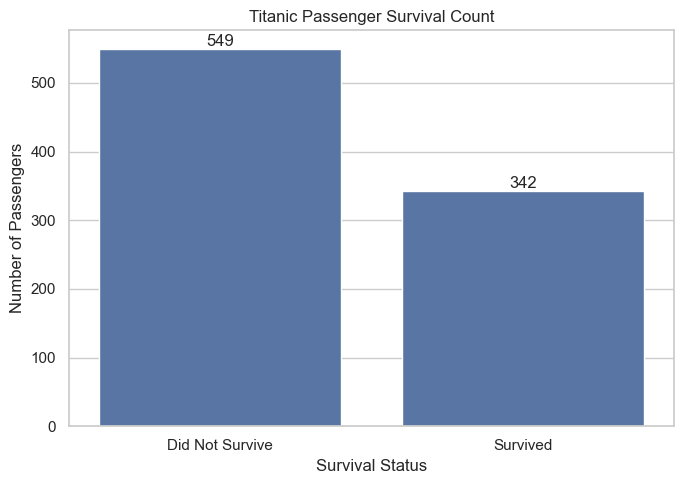

In [124]:
# Set a simple visual style for the notebook
sns.set_theme(style="whitegrid")

# Count survival outcomes
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x="Survived")

plt.title("Titanic Passenger Survival Count")
plt.xlabel("Survival Status")
plt.ylabel("Number of Passengers")
plt.xticks([0, 1], ["Did Not Survive", "Survived"])

# Add count labels above bars
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.savefig(VISUALS_PATH / "survival_count.png", dpi=300)
plt.show()

### Survival Count Interpretation

The survival count shows that 549 passengers did not survive, while 342 passengers survived. This means about 61.6% of passengers in the dataset did not survive and about 38.4% survived.

The target variable is moderately imbalanced, which is important to consider when evaluating model performance. Because of this imbalance, accuracy alone may not fully explain how well a model performs, so additional validation metrics such as a confusion matrix and classification report will be useful later in the project.

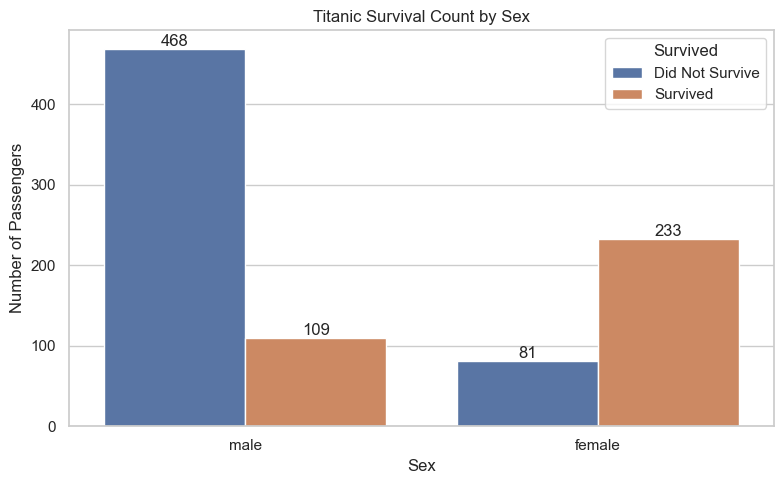

In [125]:
# Compare survival counts by sex
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x="Sex", hue="Survived")

plt.title("Titanic Survival Count by Sex")
plt.xlabel("Sex")
plt.ylabel("Number of Passengers")
plt.legend(title="Survived", labels=["Did Not Survive", "Survived"])

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.savefig(VISUALS_PATH / "survival_by_sex.png", dpi=300)
plt.show()

### Survival by Sex Interpretation

The survival count by sex shows a major difference between male and female passengers. Out of the male passengers, 468 did not survive and 109 survived. Out of the female passengers, 81 did not survive and 233 survived.

The survival rate calculation shows that about 74.2% of female passengers survived, compared to only about 18.9% of male passengers. This makes `Sex` one of the strongest early indicators of survival in the dataset and a likely important feature for the prediction models.

In [126]:
# Calculate survival rate by sex
sex_survival_rate = df.groupby("Sex")["Survived"].mean().sort_values(ascending=False)
sex_survival_rate

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

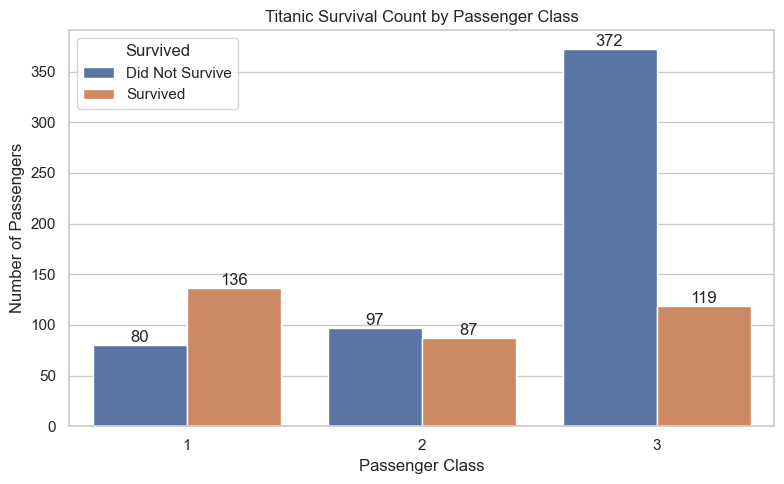

In [127]:
# Compare survival counts by passenger class
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x="Pclass", hue="Survived")

plt.title("Titanic Survival Count by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.legend(title="Survived", labels=["Did Not Survive", "Survived"])

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.savefig(VISUALS_PATH / "survival_by_passenger_class.png", dpi=300)
plt.show()

### Survival by Passenger Class Interpretation

Passenger class shows a clear relationship with survival. First-class passengers had the highest survival rate at about 63.0%, while second-class passengers had a survival rate of about 47.3%. Third-class passengers had the lowest survival rate at about 24.2%.

The count graph also shows that third-class passengers made up the largest group of passengers who did not survive, with 372 deaths compared to 119 survivors. This suggests that `Pclass` is an important feature for predicting survival and may reflect differences in passenger location, access, or priority during evacuation.

In [128]:
# Calculate survival rate by passenger class
class_survival_rate = df.groupby("Pclass")["Survived"].mean().sort_values(ascending=False)
class_survival_rate

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

### Survival by Age

Age may be useful for predicting survival, but the dataset contains missing age values. For this EDA step, I use only rows where `Age` is available so the visualization is based on known passenger ages.

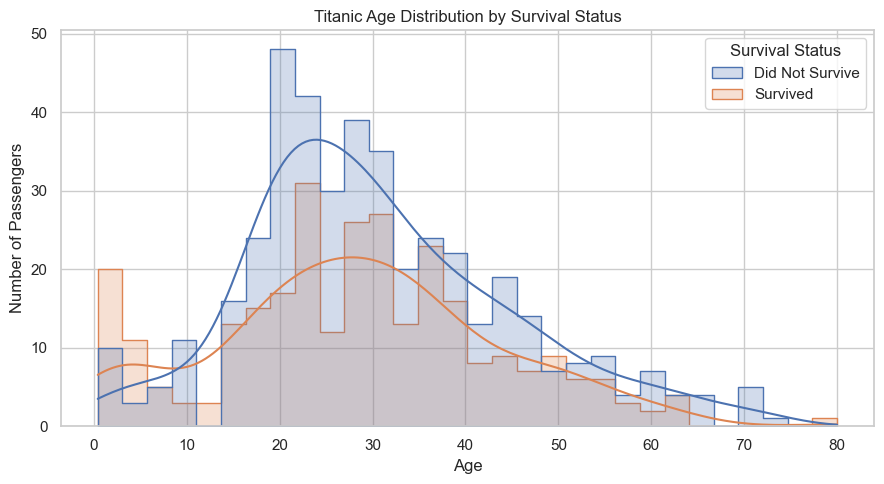

In [129]:
# Create a temporary dataset with known age values for age-based EDA
age_df = df.dropna(subset=["Age"]).copy()

# Create readable survival labels for the legend
age_df["Survival Status"] = age_df["Survived"].map({
    0: "Did Not Survive",
    1: "Survived"
})

# Compare age distribution by survival outcome
plt.figure(figsize=(9, 5))

sns.histplot(
    data=age_df,
    x="Age",
    hue="Survival Status",
    bins=30,
    kde=True,
    element="step"
)

plt.title("Titanic Age Distribution by Survival Status")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.tight_layout()
plt.savefig(VISUALS_PATH / "age_distribution_by_survival.png", dpi=300)
plt.show()

In [130]:
# Compare average age by survival outcome
age_survival_summary = df.groupby("Survived")["Age"].agg(["count", "mean", "median", "min", "max"])
age_survival_summary

,count,mean,median,min,max
Survived,,,,,
0,424,30.626179,28.0,1.00,74.0
1,290,28.343690,28.0,0.42,80.0


### Survival by Age Interpretation

The age distribution shows that both survivors and non-survivors were spread across a wide range of ages. Passengers who did not survive had an average age of about 30.6 years, while passengers who survived had an average age of about 28.3 years. The median age for both groups was 28 years.

The graph suggests that age may have some relationship with survival, especially among very young passengers, but the pattern is not as strong as features like `Sex` or `Pclass`.

Because `Age` contains missing values, it will need to be cleaned before modeling. Instead of removing all rows with missing ages, I will later fill missing age values so the model can still use the remaining passenger information.

### Survival by Family Size

The Titanic dataset separates family relationships into `SibSp`, which counts siblings or spouses aboard, and `Parch`, which counts parents or children aboard. I combine these columns to explore whether traveling alone or with family had a relationship with survival.

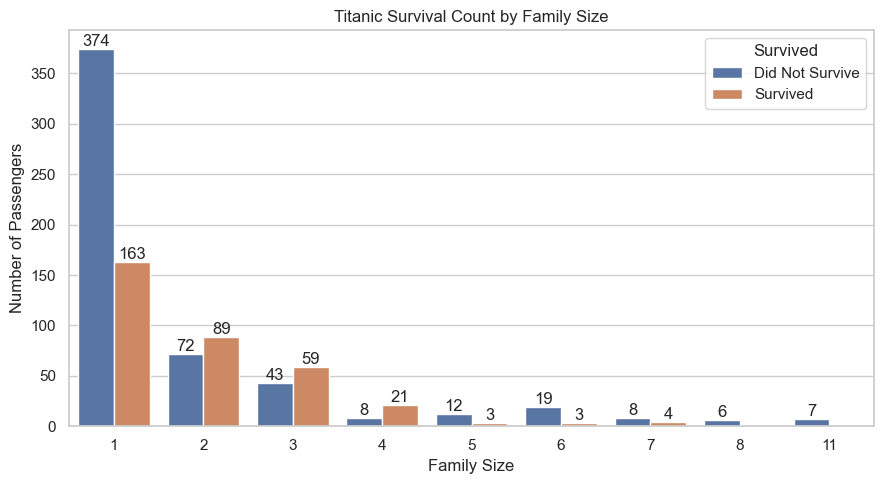

In [131]:
# Create a temporary family size column for EDA
family_df = df.copy()
family_df["FamilySize"] = family_df["SibSp"] + family_df["Parch"] + 1

# Compare survival count by family size
plt.figure(figsize=(9, 5))
ax = sns.countplot(data=family_df, x="FamilySize", hue="Survived")

plt.title("Titanic Survival Count by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Number of Passengers")
plt.legend(title="Survived", labels=["Did Not Survive", "Survived"])

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.savefig(VISUALS_PATH / "survival_by_family_size.png", dpi=300)
plt.show()

In [132]:
# Calculate survival rate by family size
family_survival_rate = family_df.groupby("FamilySize")["Survived"].mean().sort_index()
family_survival_rate

FamilySize
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64

### Survival by Family Size Interpretation

Family size appears to have a relationship with survival. Passengers traveling alone had a survival rate of about 30.4%, while passengers with a family size of 2 or 3 had higher survival rates of about 55.3% and 57.8%.

The strongest survival rate appeared for family size 4 at about 72.4%, but that group was much smaller than passengers traveling alone. Very large family groups had much lower survival outcomes, with family sizes 8 and 11 having a 0% survival rate in this dataset.

This pattern suggests that a new `FamilySize` feature may be useful for modeling. This will also help satisfy the feature engineering requirement in the data processing section.

### Survival by Embarkation Port

The `Embarked` column identifies the port where each passenger boarded the Titanic. Since this column has only two missing values, it can be explored during EDA and cleaned later during data processing.

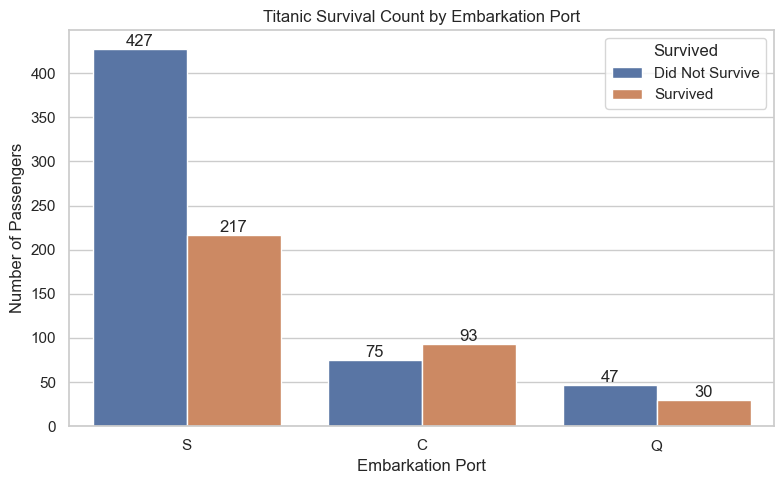

In [133]:
# Compare survival counts by embarkation port
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x="Embarked", hue="Survived")

plt.title("Titanic Survival Count by Embarkation Port")
plt.xlabel("Embarkation Port")
plt.ylabel("Number of Passengers")
plt.legend(title="Survived", labels=["Did Not Survive", "Survived"])

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.savefig(VISUALS_PATH / "survival_by_embarked.png", dpi=300)
plt.show()

In [134]:
# Calculate survival rate by embarkation port
embarked_survival_rate = df.groupby("Embarked")["Survived"].mean().sort_values(ascending=False)
embarked_survival_rate

Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64

### Survival by Embarkation Port Interpretation

The embarkation port shows some differences in survival outcomes. Passengers who boarded at port `C` had the highest survival rate at about 55.4%, while passengers who boarded at port `Q` had a survival rate of about 39.0%. Passengers who boarded at port `S` had the lowest survival rate at about 33.7%.

The count graph shows that most passengers boarded at port `S`, and this group also had the largest number of passengers who did not survive. These differences may be related to other passenger characteristics, such as passenger class, fare, or demographics.

Because `Embarked` is a categorical feature with only two missing values, it will be cleaned and encoded later for modeling.

### Survival by Fare

The `Fare` column shows how much each passenger paid. Since fare may be connected to passenger class, cabin location, and access to resources, it may have a relationship with survival.

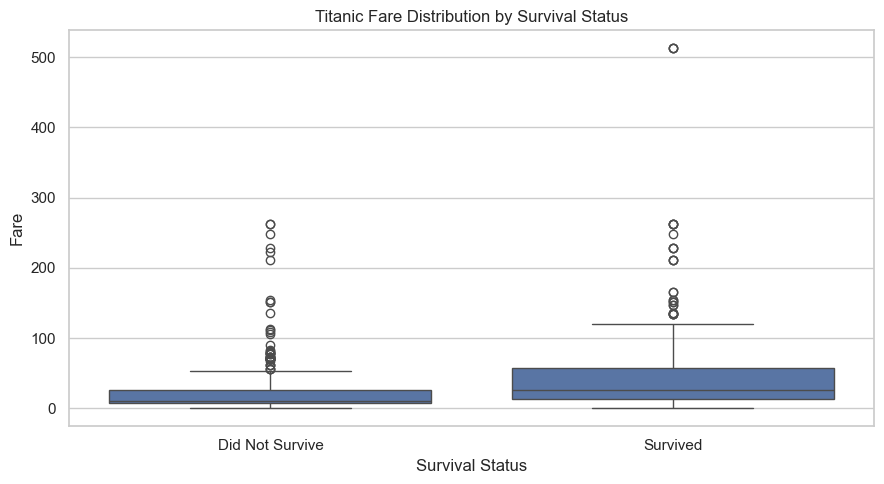

In [135]:
# Compare fare distribution by survival outcome
plt.figure(figsize=(9, 5))

sns.boxplot(data=df, x="Survived", y="Fare")

plt.title("Titanic Fare Distribution by Survival Status")
plt.xlabel("Survival Status")
plt.ylabel("Fare")
plt.xticks([0, 1], ["Did Not Survive", "Survived"])

plt.tight_layout()
plt.savefig(VISUALS_PATH / "fare_distribution_by_survival.png", dpi=300)
plt.show()

In [136]:
# Compare fare summary statistics by survival outcome
fare_survival_summary = df.groupby("Survived")["Fare"].agg(["count", "mean", "median", "min", "max"])
fare_survival_summary

,count,mean,median,min,max
Survived,,,,,
0,549,22.117887,10.5,0.0,263.0000
1,342,48.395408,26.0,0.0,512.3292


### Survival by Fare Interpretation

The fare distribution shows that passengers who survived generally paid higher fares than passengers who did not survive. Passengers who did not survive had an average fare of about 22.12 and a median fare of 10.50. Passengers who survived had an average fare of about 48.40 and a median fare of 26.00.

The boxplot also shows several high-fare outliers, including a maximum fare of 512.33 among survivors. Because of these outliers, the median fare may be more useful than the mean when interpreting typical passenger fare.

This pattern suggests that `Fare` may be useful for modeling, but it may also overlap with other features such as `Pclass`.

## 3. Data Processing and Feature Engineering

In this section, I create a cleaned version of the dataset for machine learning. This includes handling missing values, creating new features, removing columns that are not useful for modeling, and preparing categorical variables for model training.

In [137]:
# Create a copy of the original dataset for processing
processed_df = df.copy()

# Create a new feature for total family size
processed_df["FamilySize"] = processed_df["SibSp"] + processed_df["Parch"] + 1

# Create a binary feature for passengers traveling alone
processed_df["IsAlone"] = (processed_df["FamilySize"] == 1).astype(int)

processed_df[["SibSp", "Parch", "FamilySize", "IsAlone"]].head()

,SibSp,Parch,FamilySize,IsAlone
0,1,0,2,0
1,1,0,2,0
2,0,0,1,1
3,1,0,2,0
4,0,0,1,1


### Feature Engineering Notes

I created a new `FamilySize` feature by combining `SibSp`, `Parch`, and the passenger themselves. I also created an `IsAlone` feature to identify passengers who traveled without family members.

These engineered features may help the model capture survival patterns related to traveling alone or traveling with family.

In [138]:
# Check missing values before cleaning
processed_df.isnull().sum().sort_values(ascending=False)

Cabin          687
Age            177
Embarked         2
Pclass           0
Survived         0
PassengerId      0
Sex              0
Name             0
SibSp            0
Parch            0
Fare             0
Ticket           0
FamilySize       0
IsAlone          0
dtype: int64

### Handling Missing Values

The dataset has missing values in `Cabin`, `Age`, and `Embarked`. I handle each column differently based on how much data is missing and how useful the feature may be for modeling.

- `Age`: Filled with the median age because it is numeric and has a moderate number of missing values.
- `Embarked`: Filled with the most common embarkation port because only two values are missing.
- `Cabin`: Converted into a new binary feature called `HasCabin` because most cabin values are missing, but whether a cabin was recorded may still provide useful information.

In [139]:
# Fill missing Age values with the median age
processed_df["Age"] = processed_df["Age"].fillna(processed_df["Age"].median())

# Fill missing Embarked values with the most common embarkation port
processed_df["Embarked"] = processed_df["Embarked"].fillna(processed_df["Embarked"].mode()[0])

# Create a binary feature showing whether a passenger had a recorded cabin
processed_df["HasCabin"] = processed_df["Cabin"].notna().astype(int)

# Check missing values after cleaning
processed_df.isnull().sum().sort_values(ascending=False)

Cabin          687
Survived         0
PassengerId      0
Name             0
Sex              0
Age              0
Pclass           0
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         0
FamilySize       0
IsAlone          0
HasCabin         0
dtype: int64

### Column Selection

Some columns are not useful for direct machine learning modeling. `PassengerId`, `Name`, `Ticket`, and `Cabin` are removed from the modeling dataset. The original `Cabin` column is removed because it has many missing values, but the new `HasCabin` feature keeps useful information about whether a cabin was recorded.

In [140]:
# Drop columns that are not useful for direct modeling
columns_to_drop = ["PassengerId", "Name", "Ticket", "Cabin"]

processed_df = processed_df.drop(columns=columns_to_drop)

# Preview the processed dataset
processed_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone,HasCabin
0,0,3,male,22.0,1,0,7.2500,S,2,0,0
1,1,1,female,38.0,1,0,71.2833,C,2,0,1
2,1,3,female,26.0,0,0,7.9250,S,1,1,0
3,1,1,female,35.0,1,0,53.1000,S,2,0,1
4,0,3,male,35.0,0,0,8.0500,S,1,1,0


### Encoding Categorical Features

Machine learning models require numeric input, so categorical columns must be converted into numeric format. I use one-hot encoding for `Sex` and `Embarked` so the model can use these categories without treating them as ordered numeric values.

In [141]:
# Convert categorical columns into numeric columns using one-hot encoding
processed_df = pd.get_dummies(
    processed_df,
    columns=["Sex", "Embarked"],
    drop_first=True
)

# Preview encoded dataset
processed_df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize,IsAlone,HasCabin,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,2,0,0,True,False,True
1,1,1,38.0,1,0,71.2833,2,0,1,False,False,False
2,1,3,26.0,0,0,7.9250,1,1,0,False,False,True
3,1,1,35.0,1,0,53.1000,2,0,1,False,False,True
4,0,3,35.0,0,0,8.0500,1,1,0,True,False,True


In [142]:
# Convert boolean columns to integers for cleaner modeling input
bool_columns = processed_df.select_dtypes(include="bool").columns

processed_df[bool_columns] = processed_df[bool_columns].astype(int)

In [143]:
# Confirm the processed dataset has no missing values
processed_df.isnull().sum().sort_values(ascending=False)

Survived      0
Pclass        0
Age           0
SibSp         0
Parch         0
Fare          0
FamilySize    0
IsAlone       0
HasCabin      0
Sex_male      0
Embarked_Q    0
Embarked_S    0
dtype: int64

In [144]:
# View final processed dataset information
processed_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Age         891 non-null    float64
 3   SibSp       891 non-null    int64  
 4   Parch       891 non-null    int64  
 5   Fare        891 non-null    float64
 6   FamilySize  891 non-null    int64  
 7   IsAlone     891 non-null    int64  
 8   HasCabin    891 non-null    int64  
 9   Sex_male    891 non-null    int64  
 10  Embarked_Q  891 non-null    int64  
 11  Embarked_S  891 non-null    int64  
dtypes: float64(2), int64(10)
memory usage: 83.7 KB


### Processed Dataset Summary

The processed dataset now contains only numeric columns, has no missing values, and includes engineered features such as `FamilySize`, `IsAlone`, and `HasCabin`.

This cleaned dataset is ready to be split into features and target variables for machine learning.

## 4. Train-Test Split

In this section, I separate the processed dataset into features and target variables. The target variable is `Survived`, and the remaining columns are used as model features. I then split the data into training and testing sets so the models can be evaluated on data they have not seen during training.

In [145]:
from sklearn.model_selection import train_test_split

# Separate features and target variable
X = processed_df.drop(columns=["Survived"])
y = processed_df["Survived"]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (712, 11)
X_test shape: (179, 11)
y_train shape: (712,)
y_test shape: (179,)


### Train-Test Split Notes

I used an 80/20 train-test split, meaning 80% of the data is used for training and 20% is saved for testing. I also used stratification so the survival class distribution stays similar in both the training and testing sets.

## 5. Model Training

In this section, I train multiple machine learning models and compare their performance. I start with baseline models before tuning hyperparameters later in the project.

In [146]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Create baseline models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

# Train and evaluate each model
baseline_results = []

for model_name, model in models.items():
    model.fit(X_train, y_train)
    
    train_predictions = model.predict(X_train)
    test_predictions = model.predict(X_test)
    
    train_accuracy = accuracy_score(y_train, train_predictions)
    test_accuracy = accuracy_score(y_test, test_predictions)
    
    baseline_results.append({
        "Model": model_name,
        "Training Accuracy": train_accuracy,
        "Testing Accuracy": test_accuracy
    })

baseline_results_df = pd.DataFrame(baseline_results)
baseline_results_df


,Model,Training Accuracy,Testing Accuracy
0,Logistic Regression,0.807584,0.804469
1,Decision Tree,0.983146,0.793296
2,Random Forest,0.983146,0.770950


### Baseline Model Notes

I trained three baseline models: Logistic Regression, Decision Tree, and Random Forest. These models provide an early comparison before hyperparameter tuning.

Logistic Regression performed the best as a baseline model, with a training accuracy of about 80.8% and a testing accuracy of about 80.4%. Since these scores are very close, the model appears to generalize well to unseen data.

The Decision Tree and Random Forest models both had very high training accuracy at about 98.3%, but lower testing accuracy. This suggests that both models may be overfitting the training data. Hyperparameter tuning may help reduce overfitting and improve their performance.

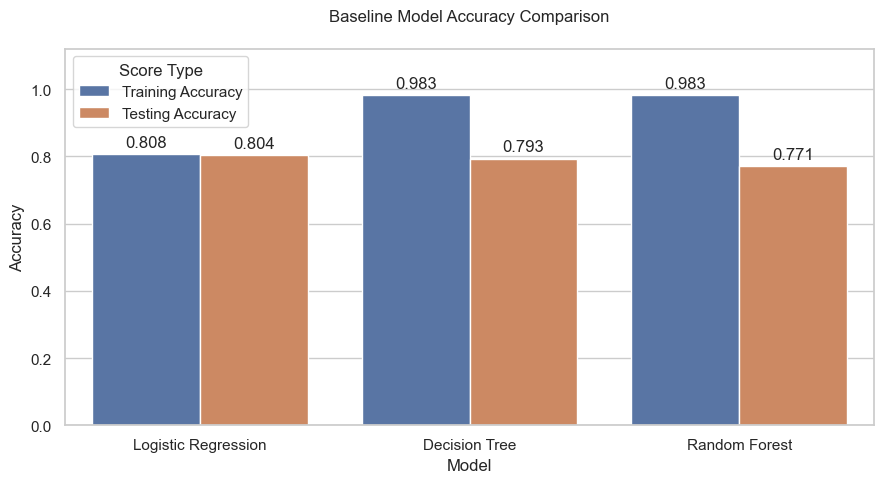

In [147]:
# Visualize baseline model performance
baseline_results_plot = baseline_results_df.melt(
    id_vars="Model",
    value_vars=["Training Accuracy", "Testing Accuracy"],
    var_name="Score Type",
    value_name="Accuracy"
)

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=baseline_results_plot,
    x="Model",
    y="Accuracy",
    hue="Score Type"
)

plt.title("Baseline Model Accuracy Comparison", pad=20)
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1.12)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

plt.tight_layout()
plt.savefig(VISUALS_PATH / "baseline_model_accuracy_comparison.png", dpi=300)
plt.show()

### Baseline Model Comparison Interpretation

The baseline model comparison shows that Logistic Regression had the most balanced training and testing performance, with a training accuracy of about 80.8% and a testing accuracy of about 80.4%.

The Decision Tree and Random Forest models performed extremely well on the training set, both reaching about 98.3% training accuracy. However, their lower testing scores suggest overfitting. The Decision Tree reached about 79.3% testing accuracy, while the Random Forest reached about 77.1%.

Because of this, the next step is to tune model hyperparameters to see whether performance can be improved while reducing overfitting.

## 6. Hyperparameter Tuning

The baseline Decision Tree and Random Forest models showed signs of overfitting because their training accuracy was much higher than their testing accuracy. In this section, I tune selected hyperparameters to improve generalization and reduce overfitting.

In [148]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid for Decision Tree
decision_tree_params = {
    "max_depth": [3, 4, 5, 6, 8, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# Create GridSearchCV for Decision Tree
decision_tree_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=decision_tree_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# Fit the grid search
decision_tree_grid.fit(X_train, y_train)

print("Best Decision Tree Parameters:", decision_tree_grid.best_params_)
print("Best Decision Tree Cross-Validation Accuracy:", decision_tree_grid.best_score_)

Best Decision Tree Parameters: {'max_depth': 4, 'min_samples_leaf': 2, 'min_samples_split': 2}
Best Decision Tree Cross-Validation Accuracy: 0.8146951639909386


In [149]:
# Define parameter grid for Random Forest
random_forest_params = {
    "n_estimators": [100, 200],
    "max_depth": [4, 6, 8, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# Create GridSearchCV for Random Forest
random_forest_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=random_forest_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# Fit the grid search
random_forest_grid.fit(X_train, y_train)

print("Best Random Forest Parameters:", random_forest_grid.best_params_)
print("Best Random Forest Cross-Validation Accuracy:", random_forest_grid.best_score_)

Best Random Forest Parameters: {'max_depth': 4, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 200}
Best Random Forest Cross-Validation Accuracy: 0.827331823106471


### Hyperparameter Tuning Notes

I used GridSearchCV to test multiple hyperparameter combinations for the Decision Tree and Random Forest models. The goal was to reduce overfitting by controlling tree depth and requiring more samples before splits or leaf nodes are created.

The best Decision Tree model used a maximum depth of 4, a minimum sample leaf size of 2, and a minimum sample split of 2. This produced a cross-validation accuracy of about 81.5%.

The best Random Forest model used 200 estimators, a maximum depth of 4, a minimum sample leaf size of 2, and a minimum sample split of 10. This produced a cross-validation accuracy of about 82.7%.

Cross-validation was used during tuning so each model could be evaluated across multiple training folds instead of relying on only one split.

## 7. Tuned Model Evaluation

After finding the best hyperparameters with GridSearchCV, I evaluate the tuned models on the testing set. This helps compare the tuned Decision Tree and Random Forest models against the original Logistic Regression baseline.

In [150]:
# Get the best tuned models
best_decision_tree = decision_tree_grid.best_estimator_
best_random_forest = random_forest_grid.best_estimator_

# Create final model comparison dictionary
final_models = {
    "Logistic Regression": models["Logistic Regression"],
    "Tuned Decision Tree": best_decision_tree,
    "Tuned Random Forest": best_random_forest
}

# Train and evaluate final models
final_results = []

for model_name, model in final_models.items():
    model.fit(X_train, y_train)
    
    train_predictions = model.predict(X_train)
    test_predictions = model.predict(X_test)
    
    train_accuracy = accuracy_score(y_train, train_predictions)
    test_accuracy = accuracy_score(y_test, test_predictions)
    
    final_results.append({
        "Model": model_name,
        "Training Accuracy": train_accuracy,
        "Testing Accuracy": test_accuracy
    })

final_results_df = pd.DataFrame(final_results)
final_results_df


,Model,Training Accuracy,Testing Accuracy
0,Logistic Regression,0.807584,0.804469
1,Tuned Decision Tree,0.834270,0.793296
2,Tuned Random Forest,0.849719,0.782123


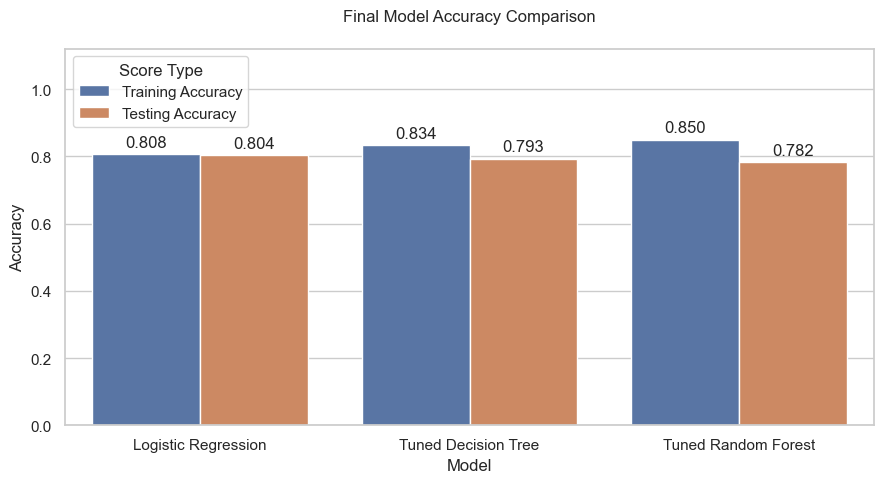

In [151]:
# Visualize final model performance
final_results_plot = final_results_df.melt(
    id_vars="Model",
    value_vars=["Training Accuracy", "Testing Accuracy"],
    var_name="Score Type",
    value_name="Accuracy"
)

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=final_results_plot,
    x="Model",
    y="Accuracy",
    hue="Score Type"
)

plt.title("Final Model Accuracy Comparison", pad=20)
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1.12)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

plt.tight_layout()
plt.savefig(VISUALS_PATH / "final_model_accuracy_comparison.png", dpi=300)
plt.show()


### Tuned Model Evaluation Notes

The tuned models were compared against the Logistic Regression baseline using training and testing accuracy. Logistic Regression had the strongest testing performance, with a training accuracy of about 80.8% and a testing accuracy of about 80.4%.

The tuned Decision Tree reached about 83.4% training accuracy and 79.3% testing accuracy. The tuned Random Forest reached about 85.0% training accuracy and 78.2% testing accuracy. Hyperparameter tuning reduced the extreme overfitting seen in the baseline tree-based models, but Logistic Regression still produced the best testing result.

Based on this comparison, Logistic Regression is selected as the final model for validation because it performs best on unseen data while maintaining the most balanced train-test accuracy.

### Final Model Selection

Logistic Regression was selected as the final model because it achieved the highest testing accuracy while maintaining the smallest gap between training and testing performance. Although the tuned Decision Tree and tuned Random Forest models improved compared to their baseline versions, they still did not outperform Logistic Regression on the testing set.

This makes Logistic Regression the strongest choice for this project because it balances predictive performance, generalization, and interpretability.

## 8. Final Model Validation

In this section, I evaluate the selected final model using a confusion matrix and classification report. Since the target variable is moderately imbalanced, accuracy alone is not enough to fully understand model performance.

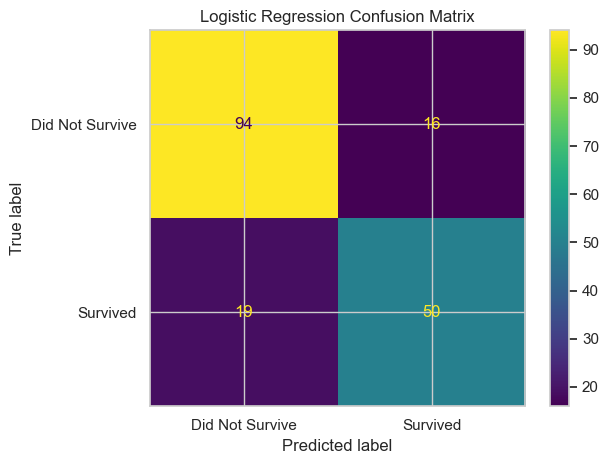

In [152]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Select final model
final_model = models["Logistic Regression"]

# Train final model
final_model.fit(X_train, y_train)

# Make predictions on testing data
final_predictions = final_model.predict(X_test)

# Create confusion matrix
cm = confusion_matrix(y_test, final_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Did Not Survive", "Survived"]
)

disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.savefig(VISUALS_PATH / "logistic_regression_confusion_matrix.png", dpi=300)
plt.show()


In [153]:
# Display classification report for final model
print(classification_report(
    y_test,
    final_predictions,
    target_names=["Did Not Survive", "Survived"]
))

                 precision    recall  f1-score   support

Did Not Survive       0.83      0.85      0.84       110
       Survived       0.76      0.72      0.74        69

       accuracy                           0.80       179
      macro avg       0.79      0.79      0.79       179
   weighted avg       0.80      0.80      0.80       179



### Final Model Validation Interpretation

The final Logistic Regression model achieved an overall testing accuracy of about 80%. The confusion matrix shows that the model correctly predicted 94 passengers who did not survive and 50 passengers who survived. It incorrectly predicted 16 passengers as surviving when they did not survive, and 19 passengers as not surviving when they actually survived.

The classification report shows that the model performed better at identifying passengers who did not survive than passengers who survived. For the `Did Not Survive` class, the model reached a precision of 0.83, recall of 0.85, and F1-score of 0.84. For the `Survived` class, the model reached a precision of 0.76, recall of 0.72, and F1-score of 0.74.

This result makes sense because the dataset has more passengers who did not survive than passengers who survived. Even though the model is not perfect, Logistic Regression provided the best balance between testing accuracy, generalization, and interpretability compared to the other models tested.

## 9. Limitations and Future Improvements

This project used a cleaned version of the Titanic dataset and compared several traditional machine learning models. While the final Logistic Regression model performed well, there are still areas that could be improved.

One limitation is that missing values were filled during the preprocessing stage before model training. In a more advanced workflow, preprocessing could be placed inside a machine learning pipeline so transformations are fit only on the training data.

Future improvements could include testing additional models, using cross-validation for final model comparison, exploring feature importance, tuning Logistic Regression hyperparameters, and creating a full preprocessing pipeline with scikit-learn.

## 10. Conclusion

This project used the Titanic passenger dataset to explore survival patterns and build machine learning models that predict passenger survival. The analysis showed that features such as `Sex`, `Pclass`, `Fare`, `FamilySize`, and `HasCabin` were useful for understanding survival differences.

During data processing, I handled missing values, encoded categorical variables, and created engineered features such as `FamilySize`, `IsAlone`, and `HasCabin`. These steps helped prepare the dataset for machine learning while keeping the notebook organized and reproducible.

I trained multiple models, including Logistic Regression, Decision Tree, and Random Forest. The Decision Tree and Random Forest models initially showed signs of overfitting, so I used GridSearchCV to tune their hyperparameters. After comparing final model performance, Logistic Regression was selected as the final model because it had the strongest testing accuracy and the most balanced train-test performance.

The final Logistic Regression model achieved about 80% testing accuracy. The confusion matrix and classification report showed that the model performed better when predicting passengers who did not survive, but it still provided useful predictions for both survival classes.

Overall, this project demonstrates a full supervised machine learning workflow, including data loading, exploratory data analysis, feature engineering, preprocessing, model comparison, hyperparameter tuning, and final validation. The final model achieved about 80% testing accuracy and showed that structured passenger features can be used to make meaningful survival predictions.